In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st
from scipy.stats import linregress
import seaborn as sns

# Atividade 2.2 - Regressão Linear, p-value e métricas

In [9]:
np.random.seed(42)

## Letra A

### Função ***LinRegress***:

A função ```scipy.stats.linregress``` calcula uma regressão linear de mínimos quadrados para dois conjuntos de medições. Ela devolve a inclinação (slope), o intercepto, o coeficiente de correlação (r-value), o p-value e o erro padrão.

### Código para plotar os gráficos

In [ ]:
def plot_graph(x : np.array, y : np.array):
    fig, ax = plt.subplots(figsize=(6, 5))
    
    ax.scatter(x, y, color='blue', zorder=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.scatter(x, [0.01] * len(x), color='green', zorder=10)
    ax.scatter([0.01] * len(y), y, color='pink', zorder=10)
    
    lr = linregress(x, y)
    
    line_x = np.array([0, 10])
    line_y = lr.slope * line_x + lr.intercept
    
    ax.plot(line_x, line_y, color='black', linestyle='--', linewidth=1)
    
    ax.set_xlabel('Gene X', fontsize=12)
    ax.set_ylabel('Gene Y', fontsize=12)

    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)

    plt.grid(color='gray', linestyle='-', linewidth=0.5)
    plt.show()
    
    return lr

### Análise dos resultados

Para a geração dos 9 valores necessários para a análise, definimos uma semente para reprodutibilidade. Os valores do primeiro gráfico são $y = x$ no intervalo $[1, 9]$. Os valores do segundo são gerados de forma aleatória para o mesmo intervalo.

--- GRÁFICO 1: CORRELAÇÃO LINEAR ---


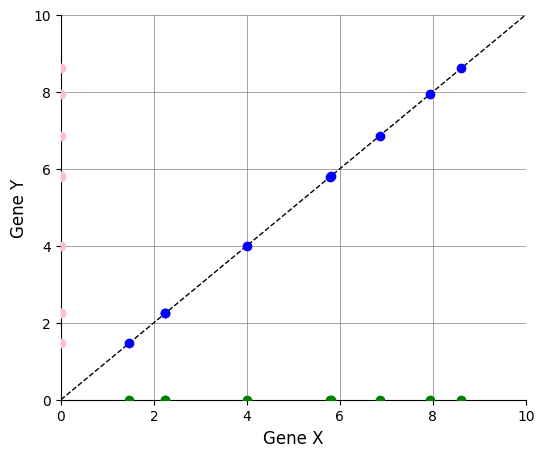

P-value: 3.2926e-70
Covariância: 6.8696
------------------------------

--- GRÁFICO 2: ALEATÓRIO (UNIFORME) ---


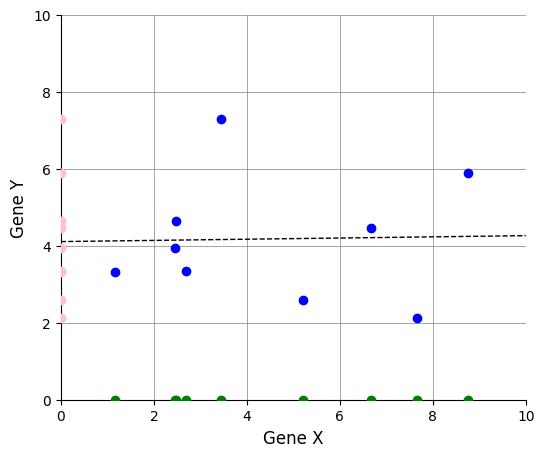

P-value: 0.9484803119891402
Covariância: 0.1098415211025765


In [ ]:
y1 = x1 = np.sort(np.random.uniform(1, 9, 9))

x2 = np.random.uniform(1, 9, 9)
y2 = np.random.uniform(1, 9, 9)

print("--- GRÁFICO 1: CORRELAÇÃO LINEAR ---")
result1 = plot_graph(x1, y1)
covariance1 = np.cov(x1, y1)[0, 1]

print(f"P-value: {result1.pvalue:.4e}")
print(f"Covariância: {covariance1:.4f}")
print("-" * 30)

print("\n--- GRÁFICO 2: ALEATÓRIO (UNIFORME) ---")
result2 = plot_graph(x2, y2)
covariance2 = np.cov(x2, y2)[0, 1]

print(f"P-value: {result2.pvalue}")
print(f"Covariância: {covariance2}")

#### **p-value**

O p-value testa a **hipótese nula** de que a inclinação da reta é zero, ou seja, que não existe correlação entre Gene X e Gene Y. 

No primeiro gráfico, observamos que o seu p-value é muito baixo, rejeitando então a **hipótese nula**. Portanto, tem uma relação estaticamente relevante entre o Gene X e o Gene Y.

Já no segundo, observamos que o seu p-value é quase $95\%$. Não podemos rejeitar a **hipotése nula**, já que mostra que o Gene X e o Gene Y não possuem correlação nenhuma.

#### **Covariância**

A covariância indica o grau de interdependência linear entre duas variáveis aleatórias, mostrando se elas se movem na mesma direção (positiva) ou em direções opostas (negativa).

No primeiro gráfico, obtemos uma covariância positiva. Já no segundo, como o valor é proximo de 0 à direita, indica que ela é ligeiramente positiva pelo acaso e não há um padrão claro de variação conjunta.

## Letra B

Usamos um *dataset* que contém dados históricos financeiros sobre o preço da prata. Possui as informações dos dias de negociações (*Date*), o preço de abertura (*Open*), o maior preço de negociação que atingiu no dia (*High*), o menor preço (*Low*), o preço final da negociação (*Close*) e o volume negociado (*Volume*). Pode-se obtê-lo no Kaggle.

In [3]:
df = pd.read_csv("../src/data/silver_prices_data.csv")
df.head()

,Date,Close,High,Low,Open,Volume
0,2011-01-24,27.318001,27.459999,26.955000,27.174999,168
1,2011-01-25,26.811001,26.950001,26.565001,26.915001,77
2,2011-01-26,27.132000,27.025000,26.684999,27.025000,49
3,2011-01-27,27.045000,27.684999,27.410000,27.684999,184
4,2011-01-28,27.934000,27.950001,26.504999,26.695000,64


Iremos utilizar apenas a coluna do preço final. Ela está na métrica **Dólares Americanos por Onça-Troy (USD/oz)**

In [32]:
df_close_prices = df['Close']
df_close_prices.head()

0    27.318001
1    26.811001
2    27.132000
3    27.045000
4    27.934000
Name: Close, dtype: float64

Para gerar o gráfico, calculamos o **erro padrão**, **desvio padrão**, **intervalo de confiança** e a **média** para cada nível de confiança.

In [ ]:
def plot_confidence_interval(mean : float, s_error : float, sd : float, ci : float, interval : tuple[float, float]):
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
   
    x = np.linspace(mean- 4*s_error, mean + 4*s_error, 1000)
    y = st.norm.pdf(x, mean, s_error)
    plt.plot(x, y, color='red')

    plt.axvline(mean, linestyle="--", color="black", lw=0.8)
    plt.axvline(interval[0], linestyle="--", color="black", lw=0.8)
    plt.axvline(interval[1], linestyle="--", color="black", lw=0.8)
    
    plt.fill_between(
        x, 0, y, 
        where=((x >= interval[0]) & (x <= interval[1])), 
        color='red', 
        alpha=0.3
        )

    plt.title(f'Nível de Confiança {ci * 100}%', fontsize=14)
    plt.xlabel('Preço final de negociação por Onça-Troy')
    plt.xticks([interval[0], mean, interval[1]])
    plt.ylabel('Distribuição das médias amostrais')
    plt.grid(True, alpha=0.3)

    plt.show()    

Tamanho da amostra: 3768
Média: 23.497272309477417
Desvio Padrão: 8.69081881208044
Intervalo de Confiaça: [23.264334857219094, 23.73020976173574]


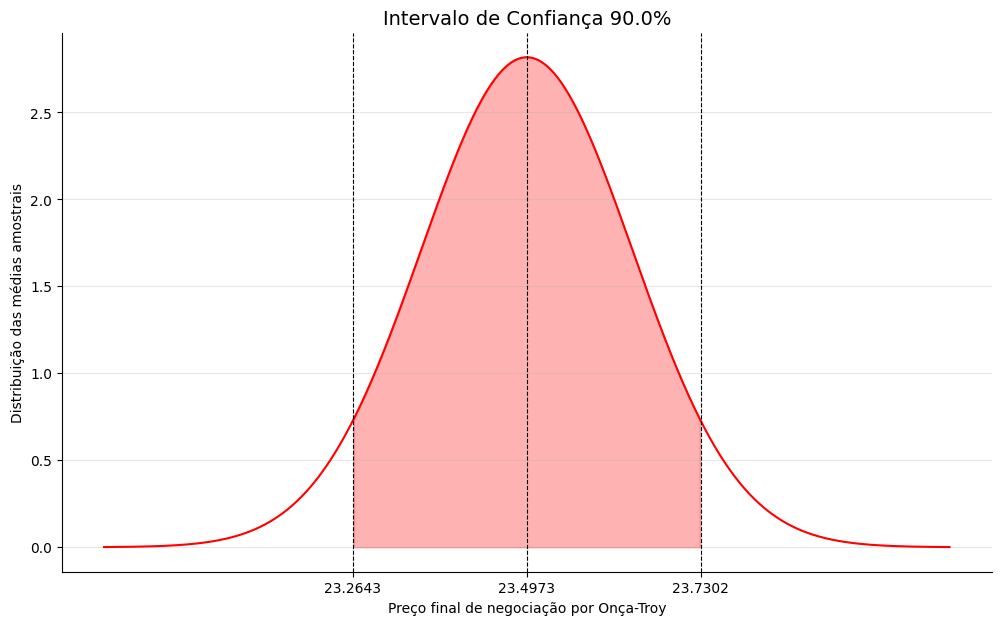

Tamanho da amostra: 3768
Média: 23.497272309477417
Desvio Padrão: 8.69081881208044
Intervalo de Confiaça: [23.219689285028643, 23.77485533392619]


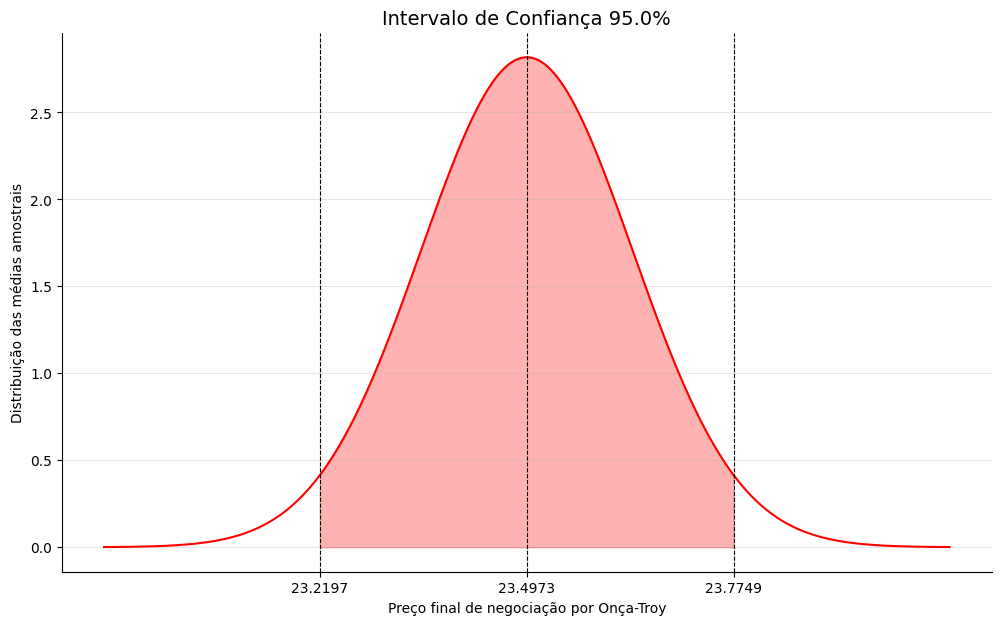

Tamanho da amostra: 3768
Média: 23.497272309477417
Desvio Padrão: 8.69081881208044
Intervalo de Confiaça: [23.13239871688576, 23.862145902069074]


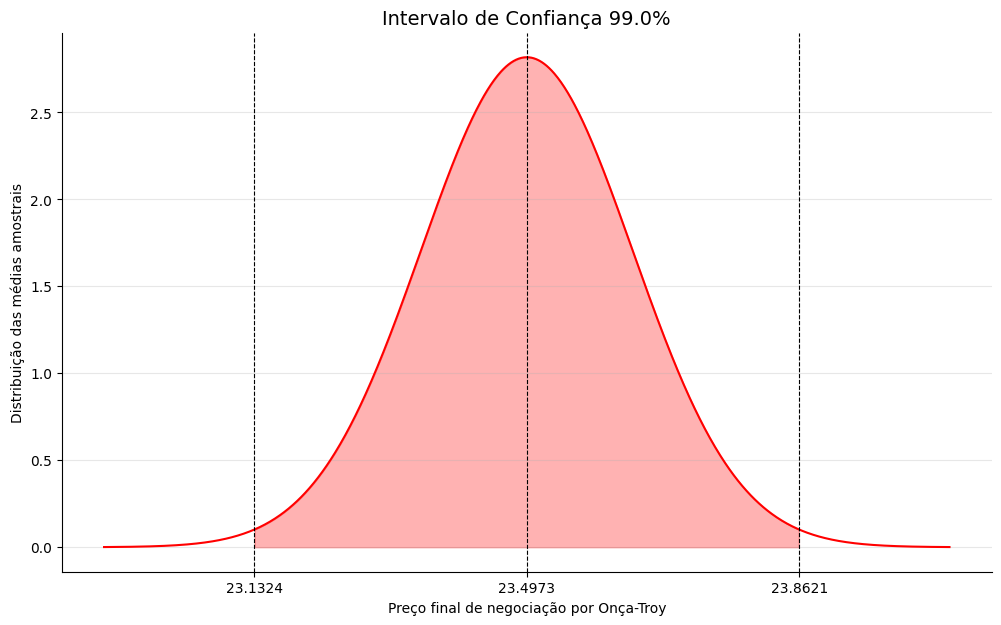

In [40]:
confidences = [0.90, 0.95, 0.99]

for confidence in confidences:
    mean = np.mean(df_close_prices)
    s_error = st.sem(df_close_prices)
    sd = np.std(df_close_prices, ddof=1)
    ci = st.t.interval(
        confidence=confidence, 
        df=len(data)-1, 
        loc=mean, 
        scale=s_error
        )

    print(f"Tamanho da amostra: {len(df_close_prices)}")
    print(f"Média: {mean}")
    print(f"Desvio Padrão: {sd}")
    print(f"Intervalo de Confiaça: [{ci[0]}, {ci[1]}]")
    plot_confidence_interval(mean, s_error, sd, confidence, ci)